# Vitor Manzano Villela Dias - 24014721
# Renan Martins Lother - 24006902

Construir um pipeline completo de classificação para o dataset CIFAR-10 (imagens 32×32 RGB, 10 classes), in-
cluindo pré-processamento, divisão treino/validação/teste com semente fixa, validação para melhoria de de-
sempenho, treinamento de uma CNN e avaliação final. O uso de Inteligência Artificial generativa para a resolução
do problema será penalizado na nota da atividade.

1. Leitura e organização do dataset
Baixe/carregue o CIFAR-10 usando a API da biblioteca escolhida. Mostre: 10 amostras aleatórias (classe e miniaturas), contagem por classe e forma dos dados.

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms
from torch.utils.data import Subset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import torch
import torchvision
import torch.nn as nn
from tqdm import tqdm
import multiprocessing
import torch.optim as optim
import torch.nn.functional as  F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms

from collections import Counter

In [ ]:
random_state = 2025
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

In [ ]:
dataset = torchvision.datasets.CIFAR10('/content/', train=True, download=True, transform=transforms.ToTensor())

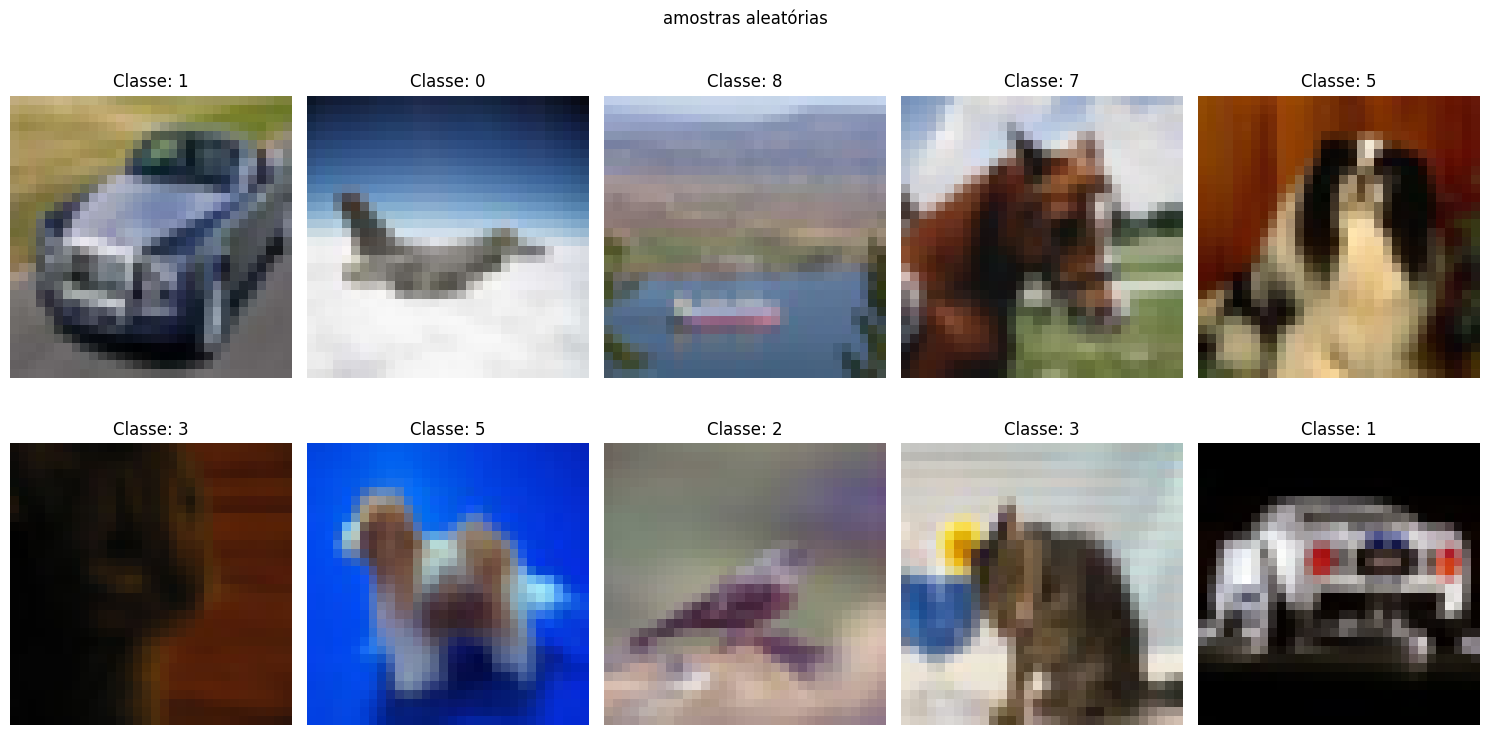

In [ ]:
indices_aleatorios = np.random.choice(len(dataset), size=10, replace=False)
amostras_aleatorias = [dataset[i] for i in indices_aleatorios]

fig, axs = plt.subplots(2, 5, figsize=(15, 8))
for ax, (img, label) in zip(axs.flatten(), amostras_aleatorias):
  ax.imshow(img.permute(1, 2, 0))
  ax.set_title(f"Classe: {label}")
  ax.axis('off')

plt.suptitle("amostras aleatórias")
plt.tight_layout()
plt.show()

In [ ]:
quantidade = Counter(dataset.targets)
print(quantidade)

Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


In [ ]:
print("Shape: ", dataset.data.shape)
print("Total de amostras: ", len(dataset))
print("Shape da imagem: ", dataset.data[0].shape)

Shape:  (50000, 32, 32, 3)
Total de amostras:  50000
Shape da imagem:  (32, 32, 3)


2. Pré-processamento e data augmentation:

Normalize as imagens para [0,1] ou padronize por canal (média e desvio do CIFAR-10). Recomenda-se augmentação leve para o conjunto de treino: RandomCrop(32, padding=4) e RandomHorizontalFlip(), podendo
incluir ColorJitter moderado.

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

In [ ]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
])

3. Divisão dos Dados em treino/validação/teste:

Realize a divisão estratificada, preservando a proporção de classes. Registre a semente (2025) na função de split
e nos geradores de lotes. Demonstre, em tabela, o número de amostras por classe em cada partição.

In [ ]:
dataset_train = torchvision.datasets.CIFAR10('/content/', train=True, download=True, transform=train_transform)
dataset_eval = torchvision.datasets.CIFAR10('/content/', train=True, download=True, transform=eval_transform)

In [ ]:
print("dataset_train:", len(dataset_train), "amostras (com augmentation)")
print("dataset_eval :", len(dataset_eval), "amostras (sem augmentation)")

dataset_train: 50000 amostras (com augmentation)
dataset_eval : 50000 amostras (sem augmentation)


In [ ]:
indices = np.arange(len(dataset_eval))
labels = dataset_eval.targets

idx_trainval, idx_test = train_test_split(
    indices,
    test_size=0.15,
    stratify=labels,
    random_state=random_state
)

print("Treino+Val:", len(idx_trainval))
print("Teste     :", len(idx_test))

Treino+Val: 42500
Teste     : 7500


In [ ]:
labels_trainval = [labels[i] for i in idx_trainval]

idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=7500/42500,
    stratify=labels_trainval,
    random_state=random_state
)

print("Treino:", len(idx_train))
print("Val   :", len(idx_val))
print("Teste :", len(idx_test))

Treino: 34999
Val   : 7501
Teste : 7500


In [ ]:
# Tabela: número de amostras por classe em cada partição
classes = dataset_train.classes

def contar(idx_list):
    return Counter([labels[i] for i in idx_list])

c_train = contar(idx_train)
c_val   = contar(idx_val)
c_test  = contar(idx_test)

tabela = pd.DataFrame({
    'Classe':   classes,
    'Treino':   [c_train[i] for i in range(10)],
    'Validação':[c_val[i]   for i in range(10)],
    'Teste':    [c_test[i]  for i in range(10)],
})
tabela.loc['Total'] = ['—', tabela['Treino'].sum(), tabela['Validação'].sum(), tabela['Teste'].sum()]
tabela

,Classe,Treino,Validação,Teste
0,airplane,3500,750,750
1,automobile,3500,750,750
2,bird,3499,751,750
3,cat,3500,750,750
4,deer,3500,750,750
5,dog,3500,750,750
6,frog,3500,750,750
7,horse,3500,750,750
8,ship,3500,750,750
9,truck,3500,750,750


4. Arquitetura sugerida de rede (CNN)
Utilize uma CNN pequena e eficiente para CIFAR-10, por exemplo:

• Layer 1: Conv(3→32, 3×3, padding=1) + BN + ReLU; Conv(32→32, 3×3, padding=1) + BN + ReLU; MaxPool(2×2).
• Layer 2: Conv(32→64, 3×3, padding=1) + BN + ReLU; Conv(64→64, 3×3, padding=1) + BN + ReLU; MaxPool(2×2).
• Head: Dropout(0.3); Flatten; Dense(256) + ReLU; Dropout(0.5); Dense(10) + Softmax (Keras) ou Logits
+ CrossEntropy (PyTorch). .

In [ ]:
class CNN_CIFAR10(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Layer 1
        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1a   = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b   = nn.BatchNorm2d(32)
        self.pool1  = nn.MaxPool2d(2, 2)

        # Layer 2
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64)
        self.pool2  = nn.MaxPool2d(2, 2)

        # Head
        self.drop1 = nn.Dropout(0.3)
        self.fc1   = nn.Linear(64 * 8 * 8, 256)
        self.drop2 = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.pool2(x)

        x = self.drop1(x)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.drop2(x)
        x = self.fc2(x)
        return x

# Verifica dimensões
modelo_teste = CNN_CIFAR10()
x_falso = torch.randn(4, 3, 32, 32)
print("Output shape:", modelo_teste(x_falso).shape)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Params:", count_parameters(modelo_teste))
print(modelo_teste)


Output shape: torch.Size([4, 10])
Params: 1117354
CNN_CIFAR10(
  (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=256, b

5. Treinamento com validação para melhoria de desempenho

Objetivo: usar a validação para model selection e evitar overfitting. Utilize os seguintes parâmetros:

In [ ]:
from torch.utils.data import Subset

batch_size = 128
generator = torch.Generator().manual_seed(random_state)

train_subset = Subset(dataset_train, idx_train)   # com augmentation
val_subset   = Subset(dataset_eval,  idx_val)     # sem augmentation
test_subset  = Subset(dataset_eval,  idx_test)    # sem augmentation

train_dataloader = DataLoader(train_subset, batch_size=batch_size,
                              shuffle=True, generator=generator, num_workers=2)
val_dataloader   = DataLoader(val_subset,   batch_size=batch_size,
                              shuffle=False, num_workers=2)
test_dataloader  = DataLoader(test_subset,  batch_size=batch_size,
                              shuffle=False, num_workers=2)

print(f"Train batches: {len(train_dataloader)} | Val: {len(val_dataloader)} | Test: {len(test_dataloader)}")


Train batches: 274 | Val: 59 | Test: 59


a. Otimizador: SGD (lr=0.1, momentum=0.9, weight decay=5e-4) ou Adam (lr=1e-3).

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

modelo = CNN_CIFAR10(num_classes=10).to(device)
net = modelo

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(modelo.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

Device: cuda


b. Agende o learning rate (ex.: redução on-plateau na métrica de validação ou marcos em épocas: 60/120).

In [ ]:
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    min_lr=1e-5,
)

epochs = 100

print("Scheduler:", lr_scheduler.__class__.__name__)
print("LR inicial:", optimizer.param_groups[0]['lr'])
print("Épocas máximas:", epochs)

Scheduler: ReduceLROnPlateau
LR inicial: 0.1
Épocas máximas: 100


c. Early stopping: pare o treino se a acurácia de validação não melhorar após 10 épocas (salve o melhor
classificador).

In [24]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc = -1.0
best_epoch = 0
epochs_sem_melhora = 0
paciencia = 10

for epoch in range(epochs):
    net.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        tr_loss    += loss.item() * images.size(0)
        tr_correct += (outputs.argmax(1) == labels).sum().item()
        tr_total   += images.size(0)

    tr_loss /= tr_total
    tr_acc   = 100.0 * tr_correct / tr_total

    net.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)

            val_loss    += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += images.size(0)

    val_loss /= val_total
    val_acc   = 100.0 * val_correct / val_total

    lr_scheduler.step(val_loss)

    # Registrar histórico
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)

    print(f"[Epoch {epoch+1:02d}] "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}% | "
          f"lr={optimizer.param_groups[0]['lr']:.5f}")

    # Salva melhor classificador e atualiza contador de early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        epochs_sem_melhora = 0
        torch.save(net.state_dict(), "best_model.pt")
        print(f"   -> novo melhor val_acc, modelo salvo")
    else:
        epochs_sem_melhora += 1
        print(f"   -> sem melhora ha {epochs_sem_melhora} epoca(s) (paciencia {paciencia})")

        if epochs_sem_melhora >= paciencia:
            print(f"\nEarly stopping disparado na epoca {epoch+1}.")
            break

print(f"\nMelhor val_acc: {best_val_acc:.2f}% na epoca {best_epoch}")


Epoch 1/100: 100%|██████████| 274/274 [00:23<00:00, 11.77it/s]


[Epoch 01] train_loss=2.1960 train_acc=15.78% | val_loss=2.0172 val_acc=21.61% | lr=0.10000
   -> novo melhor val_acc, modelo salvo


Epoch 2/100: 100%|██████████| 274/274 [00:17<00:00, 15.71it/s]


[Epoch 02] train_loss=1.9745 train_acc=22.79% | val_loss=1.8418 val_acc=25.64% | lr=0.10000
   -> novo melhor val_acc, modelo salvo


Epoch 3/100: 100%|██████████| 274/274 [00:19<00:00, 14.25it/s]


...

[Epoch 82] train_loss=0.6020 train_acc=79.20% | val_loss=0.5059 val_acc=82.34% | lr=0.00100
   -> sem melhora ha 8 epoca(s) (paciencia 10)


Epoch 83/100: 100%|██████████| 274/274 [00:17<00:00, 15.29it/s]


[Epoch 83] train_loss=0.5964 train_acc=79.67% | val_loss=0.5080 val_acc=82.20% | lr=0.00100
   -> sem melhora ha 9 epoca(s) (paciencia 10)


Epoch 84/100: 100%|██████████| 274/274 [00:18<00:00, 14.61it/s]


[Epoch 84] train_loss=0.5974 train_acc=79.39% | val_loss=0.4986 val_acc=82.76% | lr=0.00100
   -> sem melhora ha 10 epoca(s) (paciencia 10)

Early stopping disparado na epoca 84.

Melhor val_acc: 82.86% na epoca 74


d. Plote curvas treino vs. validação comparando a acurácia e a perda.

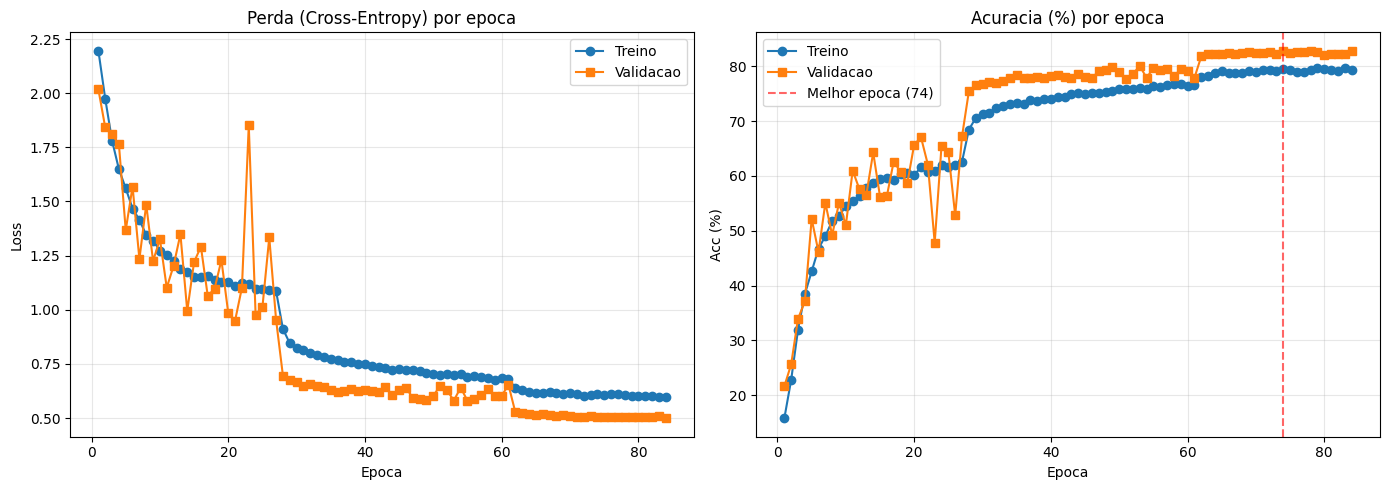

In [25]:
# acuracia e perda

epocas_rodadas = range(1, len(history["train_loss"]) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Curva de perda
axs[0].plot(epocas_rodadas, history["train_loss"], label="Treino",   marker="o")
axs[0].plot(epocas_rodadas, history["val_loss"],   label="Validacao", marker="s")
axs[0].set_title("Perda (Cross-Entropy) por epoca")
axs[0].set_xlabel("Epoca")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(alpha=0.3)

# Curva de acuracia
axs[1].plot(epocas_rodadas, history["train_acc"], label="Treino",   marker="o")
axs[1].plot(epocas_rodadas, history["val_acc"],   label="Validacao", marker="s")
axs[1].axvline(x=best_epoch, color="red", linestyle="--", alpha=0.6,
               label=f"Melhor epoca ({best_epoch})")
axs[1].set_title("Acuracia (%) por epoca")
axs[1].set_xlabel("Epoca")
axs[1].set_ylabel("Acc (%)")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


6. Avaliação no conjunto de teste

Carregue o melhor classificador salvo (segundo validação) e reporte a acurácia final de teste, a matriz de confusão e o relatório de classificação por classe. Discuta onde o modelo erra mais e quais classes são mais confusas.

In [26]:
# Carrega o melhor classificador salvo durante a validacao
net.load_state_dict(torch.load("best_model.pt"))
net.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        outputs = net(images)
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

acuracia_teste = accuracy_score(all_labels, all_preds) * 100
print(f"Acuracia final no conjunto de teste: {acuracia_teste:.2f}%")


Acuracia final no conjunto de teste: 81.80%


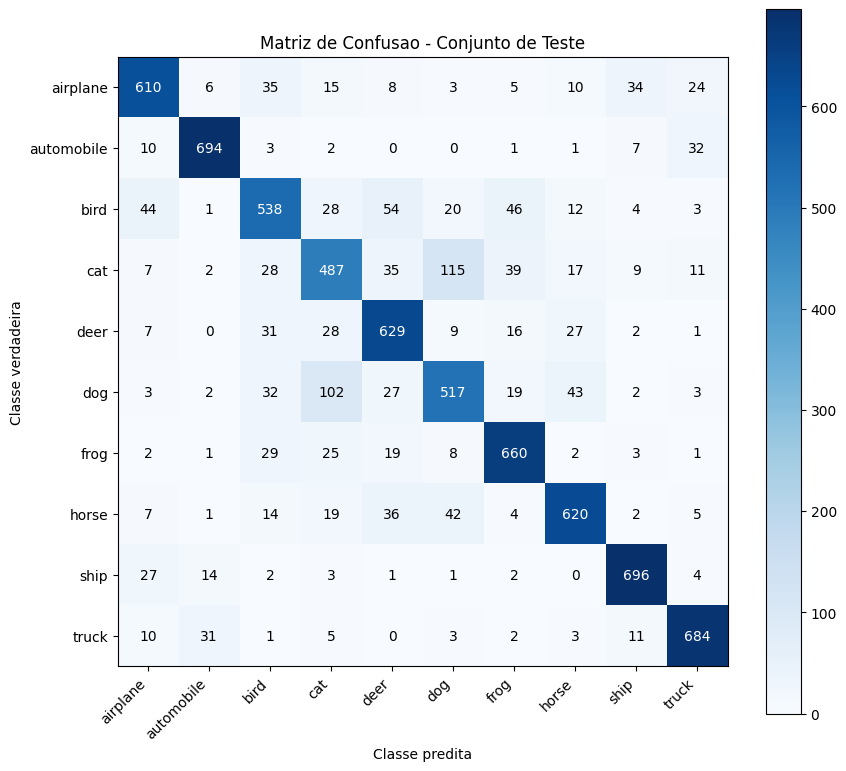

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

# Matriz de confusão
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.figure.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe verdadeira")
ax.set_title("Matriz de Confusao - Conjunto de Teste")

# Escrever o valor de cada celula
limiar = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > limiar else "black")

plt.tight_layout()
plt.show()

In [28]:
# Relatorio de classificacao por classe
from sklearn.metrics import classification_report

classes = dataset_train.classes
relatorio = classification_report(
    all_labels, all_preds,
    target_names=classes,
    digits=4,
)
print(relatorio)

              precision    recall  f1-score   support

    airplane     0.8391    0.8133    0.8260       750
  automobile     0.9229    0.9253    0.9241       750
        bird     0.7546    0.7173    0.7355       750
         cat     0.6821    0.6493    0.6653       750
        deer     0.7775    0.8387    0.8069       750
         dog     0.7201    0.6893    0.7044       750
        frog     0.8312    0.8800    0.8549       750
       horse     0.8435    0.8267    0.8350       750
        ship     0.9039    0.9280    0.9158       750
       truck     0.8906    0.9120    0.9012       750

    accuracy                         0.8180      7500
   macro avg     0.8165    0.8180    0.8169      7500
weighted avg     0.8165    0.8180    0.8169      7500



In [29]:
import numpy as np

cm_sem_diagonal = cm.copy()
np.fill_diagonal(cm_sem_diagonal, 0)

pares = []
for i in range(10):
    for j in range(10):
        if i != j and cm_sem_diagonal[i, j] > 0:
            pares.append((cm_sem_diagonal[i, j], classes[i], classes[j]))

pares.sort(reverse=True)
print("Top 5 confusoes (classe verdadeira -> predita):\n")
for n, verd, pred in pares[:5]:
    print(f"  {verd:>12s} -> {pred:<12s}: {n} erros")

# Acuracia por classe
print("\nAcuracia por classe:\n")
for i, nome in enumerate(classes):
    total_classe = cm[i].sum()
    acertos = cm[i, i]
    print(f"  {nome:>12s}: {100 * acertos / total_classe:.2f}%  ({acertos}/{total_classe})")


Top 5 confusoes (classe verdadeira -> predita):

           cat -> dog         : 115 erros
           dog -> cat         : 102 erros
          bird -> deer        : 54 erros
          bird -> frog        : 46 erros
          bird -> airplane    : 44 erros

Acuracia por classe:

      airplane: 81.33%  (610/750)
    automobile: 92.53%  (694/750)
          bird: 71.73%  (538/750)
           cat: 64.93%  (487/750)
          deer: 83.87%  (629/750)
           dog: 68.93%  (517/750)
          frog: 88.00%  (660/750)
         horse: 82.67%  (620/750)
          ship: 92.80%  (696/750)
         truck: 91.20%  (684/750)


Discussao dos resultados


1. Onde o modelo erra mais? classes visualmente parecidas se confundam (gato/cachorro, automovel/caminhao, cervo/cavalo).
2. Quais classes tem menor acuracia individual? Cat, dog e bird tem as piores acurácias, a menor sendo 64.93% (cat) e a média entre as 3 sendo: 68.53
3. O early stopping ajudou? Sim, foi um bom proxy já que a acurácia final do teste e o melhor modelo foram parecidos, sendo respectivamente: 81.90% e 82.86%
